## 5.2 합성곱 신경망 맛보기
fashion_mnist 데이터셋 이용해 CNN 구현하기 <br>
- 토치비전 내장 데이터: 운동화, 셔츠, 샌들 등 작은 이미지 모음
- 28x28px의 이미지 7만 개로 구성
- 훈련 데이터: 0-255 값의 28x28 크기 넘파이 배열
- 레이블 데이터: 0-9 정수 값 가지는 배열 (이미지 클래스 분류하는 레이블)

### 데이터 다운로드 및 로드

In [1]:
import numpy as np
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
from torch.autograd import Variable
import torch.nn.functional as F

import torchvision
import torchvision.transforms as transforms # 데이터 전처리용 라이브러리
from torch.utils.data import Dataset, DataLoader

In [2]:
# cpu/gpu 장치 확인
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")

In [5]:
from google.colab import drive
drive.mount('/content/drive')

root="/content/drive/MyDrive/data"

Mounted at /content/drive


In [6]:
# 데이터셋 다운로드
train_dataset = torchvision.datasets.FashionMNIST(root=root,
    download=True,
    transform=transforms.Compose([transforms.ToTensor()]))

test_dataset = torchvision.datasets.FashionMNIST(root=root,
    download=True,
    train=False,
    transform=transforms.Compose([transforms.ToTensor()]))

100%|██████████| 26.4M/26.4M [00:01<00:00, 18.3MB/s]
100%|██████████| 29.5k/29.5k [00:00<00:00, 327kB/s]
100%|██████████| 4.42M/4.42M [00:00<00:00, 5.66MB/s]
100%|██████████| 5.15k/5.15k [00:00<00:00, 11.2MB/s]


In [7]:
# 데이터를 로더에 전달
train_loader = torch.utils.data.DataLoader(train_dataset, batch_size=100)
test_loader = torch.utils.data.DataLoader(test_dataset, batch_size=100)

### 분류에 사용할 클래스 정의

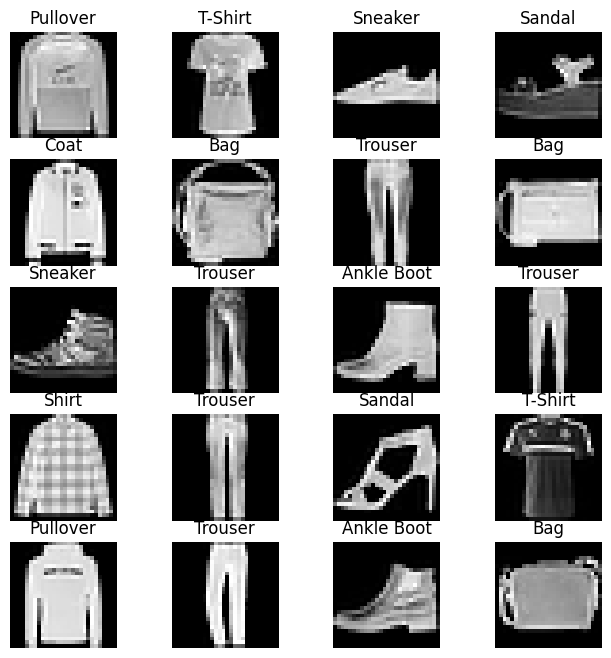

In [8]:
labels_map = {0: 'T-Shirt', 1: 'Trouser', 2: 'Pullover', 3: 'Dress', 4: 'Coat',
              5: 'Sandal', 6: 'Shirt', 7: 'Sneaker', 8: 'Bag', 9: 'Ankle Boot'}

fig = plt.figure(figsize=(8,8)); # 출력할 이미지의 크기 지정
columns = 4;
rows = 5;

for i in range(1, columns*rows+1):
  img_xy = np.random.randint(len(train_dataset));
  img = train_dataset[img_xy][0][0, :, :] # 훈련 데이터셋 이용해 3차원 배열 생성
  fig.add_subplot(rows, columns, i)
  plt.title(labels_map[train_dataset[img_xy][1]])
  plt.axis('off')
  plt.imshow(img, cmap='gray')
plt.show()

### 심층 신경망

In [9]:
# 심층 신경망 먼저 생성한 후 학습 (Not CNN. 비교를 위해...)
class FashionDNN(nn.Module):
  def __init__(self):
    super(FashionDNN, self).__init__()
    self.fc1 = nn.Linear(in_features=784, out_features=256)
    self.drop = nn.Dropout(0.25)
    self.fc2 = nn.Linear(in_features=256, out_features=128)
    self.fc3 = nn.Linear(in_features=128, out_features=10)

  def forward(self, input_data):
    out = input_data.view(-1, 784)
    out = F.relu(self.fc1(out))
    out = self.drop(out)
    out = F.relu(self.fc2(out))
    out = self.fc3(out)
    return out

#### 코드 설명
- in_features: 입력의 크기
- out_features: 출력의 크기

실제 연산이 진행되는 forward() 부분에서는 첫 번째 파라미터 값만 전달되고, 두 번째 파라미터가 forward() 연산의 결과가 됨.

- nn.Dropout(p): p만큼의 비율로 텐서 값이 0이 되고, 0이 되지 않는 값들은 기존 값에 1/(1-p)만큼 곱해져 커짐.
- view: 텐서 크기 변경. (-1, 784)는 input_data를 (?, 784)로 변경. 첫 번째 차원은 파이토치가 알아서 조정하라는 의미.

In [10]:
# 파라미터 정의
learning_rate = 0.001;
model = FashionDNN();
model.to(device)

criterion = nn.CrossEntropyLoss(); # 분류 문제에서 사용하는 손실 함수
optimizer = torch.optim.Adam(model.parameters(), lr=learning_rate); # 경사하강법 Adam 사용
print(model)

FashionDNN(
  (fc1): Linear(in_features=784, out_features=256, bias=True)
  (drop): Dropout(p=0.25, inplace=False)
  (fc2): Linear(in_features=256, out_features=128, bias=True)
  (fc3): Linear(in_features=128, out_features=10, bias=True)
)


In [14]:
# DNN에 데이터 적용해 모델 학습시키기
num_epochs = 5
count = 0
loss_list = []
iteration_list = []
accuracy_list = []

predictions_list = []
labels_list = []

for epoch in range(num_epochs):
  for images, labels in train_loader:
    images, labels = images.to(device), labels.to(device)

    train = Variable(images.view(100, 1, 28, 28))
    labels = Variable(labels)

    # 학습 데이터를 모델에 적용
    outputs = model(train)
    loss = criterion(outputs, labels)
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()
    count += 1

    if not (count % 50):
      total = 0
      correct = 0
      for images, labels in test_loader:
        images, labels = images.to(device), labels.to(device)
        labels_list.append(labels)
        test = Variable(images.view(100, 1, 28, 28))
        outputs = model(test)
        predictions = torch.max(outputs, 1)[1].to(device)
        predictions_list.append(predictions)
        correct += (predictions == labels).sum()
        total += len(labels)

      accuracy = correct * 100 / total
      loss_list.append(loss.data)
      iteration_list.append(count)
      accuracy_list.append(accuracy)

    if not (count % 500):
      print("Iteration: {}, Loss: {}, Accuracy: {}%".format(count, loss.data, accuracy))

Iteration: 500, Loss: 0.6000848412513733, Accuracy: 83.44000244140625%
Iteration: 1000, Loss: 0.4548647701740265, Accuracy: 84.9000015258789%
Iteration: 1500, Loss: 0.34675872325897217, Accuracy: 84.44999694824219%
Iteration: 2000, Loss: 0.35998451709747314, Accuracy: 85.66999816894531%
Iteration: 2500, Loss: 0.24092429876327515, Accuracy: 85.94000244140625%
Iteration: 3000, Loss: 0.27824077010154724, Accuracy: 86.52999877929688%


### 합성곱 신경망 CNN

In [24]:
# 합성곱 네트워크 생성
class FashionCNN(nn.Module):
  def __init__(self):
    super(FashionCNN, self).__init__()
    self.layer1 = nn.Sequential(
      nn.Conv2d(in_channels=1, out_channels=32, kernel_size=3, padding=1), # Conv2d 적용
      nn.BatchNorm2d(32),
      nn.ReLU(),
      nn.MaxPool2d(kernel_size=2, stride=2)
    )

    self.layer2 = nn.Sequential(
      nn.Conv2d(in_channels=32, out_channels=64, kernel_size=3),
      nn.BatchNorm2d(64),
      nn.ReLU(),
      nn.MaxPool2d(2)
    )

    self.fc1 = nn.Linear(in_features=64*6*6, out_features=600)
    self.drop = nn.Dropout2d(0.25)
    self.fc2 = nn.Linear(in_features=600, out_features=120)
    self.fc3 = nn.Linear(in_features=120, out_features=10) # 10: 클래스 개수

  def forward(self, x):
    out = self.layer1(x)
    out = self.layer2(out)
    out = out.view(out.size(0), -1)
    out = self.fc1(out)
    out = self.drop(out)
    out = self.fc2(out)
    out = self.fc3(out)
    return out

In [26]:
# 합성곱 네트워크를 위한 파라미터 정의
learning_rate = 0.001;
model = FashionCNN();
model.to(device)

criterion = nn.CrossEntropyLoss();
optimizer = torch.optim.Adam(model.parameters(), lr=learning_rate);
print(model)

FashionCNN(
  (layer1): Sequential(
    (0): Conv2d(1, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (layer2): Sequential(
    (0): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1))
    (1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (fc1): Linear(in_features=2304, out_features=600, bias=True)
  (drop): Dropout2d(p=0.25, inplace=False)
  (fc2): Linear(in_features=600, out_features=120, bias=True)
  (fc3): Linear(in_features=120, out_features=10, bias=True)
)


In [28]:
# CNN에 데이터 적용해 모델 학습시키기
num_epochs = 5
count = 0
loss_list = []
iteration_list = []
accuracy_list = []

predictions_list = []
labels_list = []

for epoch in range(num_epochs):
  for images, labels in train_loader:
    images, labels = images.to(device), labels.to(device)

    train = Variable(images.view(100, 1, 28, 28))
    labels = Variable(labels)

    # 학습 데이터를 모델에 적용
    outputs = model(train)
    loss = criterion(outputs, labels)
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()
    count += 1

    if not (count % 50):
      total = 0
      correct = 0
      for images, labels in test_loader:
        images, labels = images.to(device), labels.to(device)
        labels_list.append(labels)
        test = Variable(images.view(100, 1, 28, 28))
        outputs = model(test)
        predictions = torch.max(outputs, 1)[1].to(device)
        predictions_list.append(predictions)
        correct += (predictions == labels).sum()
        total += len(labels)

      accuracy = correct * 100 / total
      loss_list.append(loss.data)
      iteration_list.append(count)
      accuracy_list.append(accuracy)

    if not (count % 500):
      print("Iteration: {}, Loss: {}, Accuracy: {}%".format(count, loss.data, accuracy))

Iteration: 500, Loss: 0.2391732633113861, Accuracy: 91.05000305175781%
Iteration: 1000, Loss: 0.18842992186546326, Accuracy: 89.87999725341797%
Iteration: 1500, Loss: 0.06646131724119186, Accuracy: 90.02999877929688%
Iteration: 2000, Loss: 0.1638677567243576, Accuracy: 90.27999877929688%
Iteration: 2500, Loss: 0.1492127627134323, Accuracy: 89.77999877929688%
Iteration: 3000, Loss: 0.11005957424640656, Accuracy: 89.80000305175781%
